
AI-POWERED CLAIMS ASSESSMENT SYSTEM - DEMO

Initializing Claims Assessment System...
✅ Damage detection model loaded successfully!
✅ YOLO severity model loaded from: /home/prakhargupta/Desktop/Megathon-25/MEGATHON25/car-damage.pt
⚠ Note: Using edge-based saliency map instead of GradCAM for YOLO model
System initialized successfully!

--------------------------------------------------------------------------------
TEST CASE 1: Sample Image Assessment
--------------------------------------------------------------------------------

Processing claim...

✓ Image quality: 0.94
✓ Damage detected: 00-damage (confidence: 99.82%)

0: 128x128 03-severe 0.67, 02-moderate 0.26, 01-minor 0.07, 9.2ms
Speed: 1.4ms preprocess, 9.2ms inference, 0.1ms postprocess per image at shape (1, 3, 128, 128)
✓ Severity: severe (confidence: 67.30%)
✓ Fraud risk: MEDIUM (59.00%)
  Indicators: High ELA variance detected (max diff: 241), indicates potential tampering., Could not parse EXIF metadata (potentially stri

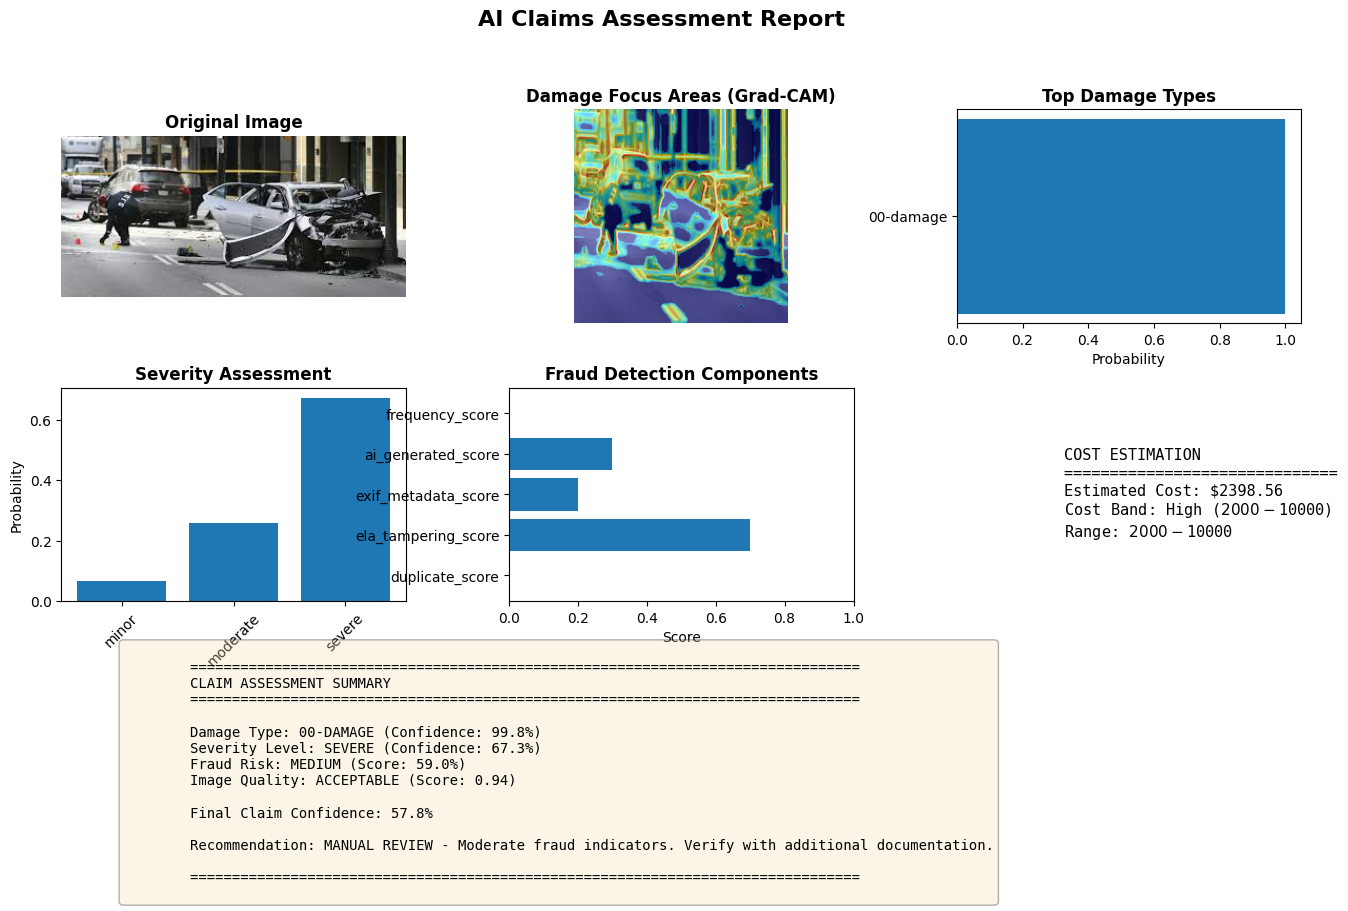


DEMO COMPLETED


✓ System ready for use!

To assess your own images:
  results = system.assess_claim('test_2.jpg')


In [5]:

import torch
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import hashlib
import imagehash
from datetime import datetime
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')
from ultralytics import YOLO
from PIL import Image
from io import BytesIO
import requests
import os
from PIL import ExifTags
import kagglehub


from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image


# ============================================================================
# SECTION 2: CONFIGURATION AND CONSTANTS
# ============================================================================

class Config:
    """Central configuration for the system"""
    
    # Model paths
    DAMAGE_MODEL_PATH = "/home/prakhargupta/Desktop/Megathon-25/MEGATHON25/best.pt"
    SEVERITY_MODEL_PATH = "/home/prakhargupta/Desktop/Megathon-25/MEGATHON25/car-damage.pt"
    
    # Image parameters
    IMAGE_SIZE = 224
    
    # Damage types
    DAMAGE_TYPES = [
        'scratch', 'dent', 'broken_glass', 'broken_lamp', 
        'bumper_damage', 'door_damage', 'hood_damage', 'no_damage'
    ]
    
    # Severity levels
    SEVERITY_LEVELS = ['minor', 'moderate', 'severe']
    
    # Cost bands (in USD)
    COST_BANDS = {
        'minor': (100, 500),
        'moderate': (500, 2000),
        'severe': (2000, 10000)
    }
    
    # Fraud thresholds
    FRAUD_THRESHOLD_HIGH = 0.7
    FRAUD_THRESHOLD_MEDIUM = 0.4
    
    # Device
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

config = Config()

# ============================================================================
# SECTION 3: DATA PREPROCESSING AND AUGMENTATION
# ============================================================================
class ImagePreprocessor:
    """Handles image preprocessing, quality checks, and enhancement"""

    def __init__(self, image_size=224):
        self.image_size = image_size
        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

    def preprocess(self, image_path, enhance_if_needed=True):
        """Load and preprocess image"""
        if isinstance(image_path, str):
            image = Image.open(image_path).convert('RGB')
        else:
            image = image_path.convert('RGB')

        quality_score = self._check_image_quality(image)

        # Enhance if blur detected
        if enhance_if_needed and not quality_score['is_acceptable']:
            image = self._enhance_image(image, quality_score)

        tensor = self.transform(image)
        return tensor, image, quality_score

    def _check_image_quality(self, image):
        """Check image quality (blur, brightness)"""
        img_array = np.array(image)
        gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)

        # Blur detection
        blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()

        # Brightness check
        brightness = np.mean(gray)

        # Normalize
        blur_quality = min(blur_score / 500, 1.0)
        brightness_quality = 1.0 - abs(brightness - 127.5) / 127.5
        overall_quality = (blur_quality * 0.6 + brightness_quality * 0.4)

        return {
            'blur_score': blur_score,
            'brightness': brightness,
            'overall_quality': overall_quality,
            'is_acceptable': blur_score > 100 and 30 < brightness < 225
        }

    def _enhance_image(self, image, quality):
        """Enhance blurred or low-quality image using DIP techniques"""
        img = np.array(image)
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

        # If blurred, apply Unsharp Masking
        if quality['blur_score'] < 100:
            blurred = cv2.GaussianBlur(img, (0, 0), 3)
            img = cv2.addWeighted(img, 1.5, blurred, -0.5, 0)

        # Brightness/contrast enhancement using CLAHE
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        gray_eq = clahe.apply(gray)
        img = cv2.cvtColor(gray_eq, cv2.COLOR_GRAY2RGB)

        # Optional denoising (if needed)
        img = cv2.bilateralFilter(img, d=9, sigmaColor=75, sigmaSpace=75)

        return Image.fromarray(img)


# ============================================================================
# SECTION 4: DAMAGE DETECTION MODEL
# ============================================================================

class DamageDetectionModel:
    """
    A class to load and use the trained YOLOv8 car damage classification model.
    """
    def __init__(self, model_path: str):
        """
        Loads the YOLOv8 model from the specified file path.
        """
        if not os.path.exists(model_path):
            raise FileNotFoundError(f"Model file not found at path: {model_path}")
        
        try:
            self.model = YOLO(model_path)
            print("✅ Damage detection model loaded successfully!")
        except Exception as e:
            raise IOError(f"Failed to load the model. Error: {e}")

    def predict(self, image_path: str) -> dict:
        """
        Takes an image file path as input, opens the image, and returns a
        prediction of whether the car is damaged or not.
        """
        if not os.path.exists(image_path):
            return {"error": f"Image not found at path: {image_path}"}
            
        try:
            # --- MODIFICATION START ---
            # Manually open the image using PIL, which we know works.
            img = Image.open(image_path)
            
            # Pass the loaded PIL image object to the model, not the file path string.
            results = self.model.predict(img, verbose=False)
            # --- MODIFICATION END ---
            
            # Extract the top prediction from the results
            result = results[0]
            predicted_class_index = result.probs.top1
            predicted_class_name = self.model.names[predicted_class_index]
            confidence_score = result.probs.top1conf.item() * 100
            
            return {
                "prediction": predicted_class_name,
                "confidence": round(confidence_score, 2)
            }
        except Exception as e:
            return {"error": f"An error occurred during prediction: {e}"}




class SeverityAssessmentModel():
    """
    Wrapper around a YOLOv8 classification model for damage severity assessment.
    Compatible with the existing API used in ClaimsAssessmentSystem.
    """


    def __init__(self, num_severity_levels=3, pretrained=True, model_path=None):
        # super(SeverityAssessmentModel, self).__init__()


        # You can ignore `num_severity_levels` and `pretrained` here,
        # they are just to maintain API compatibility with the pipeline.
        # Load the pretrained YOLOv8 classification model
        self.class_names = ["minor", "moderate", "severe"]
        self.model_path = model_path or "/home/prakhargupta/Desktop/Megathon-25/MEGATHON25/car-damage.pt"
        self.model = YOLO(self.model_path)
        print(f"✅ YOLO severity model loaded from: {self.model_path}")


    # def forward(self, x):
    #     """
    #     The forward() method isn't used directly since YOLO runs inference
    #     on PIL or numpy images. This is kept for API consistency.
    #     """
    #     return x


    def predict(self, image_input):
        """
        Performs inference and returns severity probabilities and predicted class.
        Accepts:
          - image_input: file path, URL, or PIL.Image object
        Returns:
          - probabilities: dict of class → probability
          - predicted_class: str (minor/moderate/severe)
        """


        # --- Step 1: Load image ---
        if isinstance(image_input, Image.Image):
            image = image_input
        elif isinstance(image_input, str):
            image = Image.open(image_input)
        else:
            raise ValueError("Unsupported image input type")


        # --- Step 2: Run YOLO inference ---
        results = self.model(image)
        probs = results[0].probs


        if probs is None:
            raise RuntimeError("YOLO model did not return probabilities (check model type)")


        prob_values = probs.data.tolist()
        predicted_idx = probs.top1
        predicted_class = self.class_names[predicted_idx]


        probabilities = dict(zip(self.class_names, prob_values))


        return probabilities, predicted_class
# ============================================================================
# SECTION 6: FRAUD DETECTION MODULE
# ============================================================================

class FraudDetector:
    """Detects potential fraud through multiple, enhanced checks"""

    def __init__(self):
        self.image_hashes = {}
        self.submission_history = []

    def detect_fraud(self, image, claim_text=None):
        fraud_indicators = []
        fraud_score = 0.0

        # --- UPDATED: Call all new and old checks ---
        checks = {
            'duplicate': (self._check_duplicate(image), 0.4), # High weight
            'ela_tampering': (self._detect_ela_tampering(image), 0.5), # Very high weight
            'exif_metadata': (self._analyze_metadata(image), 0.6), # Very high weight
            'ai_generated': (self._detect_ai_generation(image), 0.4), # High weight
            'frequency': (self._check_submission_frequency(), 0.2) # Lower weight
        }

        details = {}
        for check_name, (result, weight) in checks.items():
            score, reason = result
            details[f'{check_name}_score'] = score
            if score > 0:
                fraud_indicators.append(reason)
                fraud_score += score * weight
        
        fraud_score = min(fraud_score, 1.0) # Cap the score at 1.0

        return {
            'fraud_score': fraud_score,
            'fraud_level': self._get_fraud_level(fraud_score),
            'indicators': fraud_indicators if fraud_indicators else ["No obvious fraud indicators found."],
            'details': details
        }

    # --- NEW: Error Level Analysis ---
    def _detect_ela_tampering(self, image, quality=90, scale=15):
        temp_filename = "temp_ela.jpg"
        try:
            image.save(temp_filename, 'JPEG', quality=quality)
            resaved_image = Image.open(temp_filename)
            ela_image = Image.fromarray(np.abs(np.array(image) - np.array(resaved_image)) * scale)
            extrema = ela_image.getextrema()
            max_diff = max([ex[1] for ex in extrema]) if extrema else 0
        finally:
            if os.path.exists(temp_filename):
                os.remove(temp_filename)

        if max_diff > 100:
            return 0.7, f"High ELA variance detected (max diff: {max_diff}), indicates potential tampering."
        return 0.0, ""

    # --- NEW: AI Generation Check ---
    def _detect_ai_generation(self, image):
        img_array = np.array(image.convert('RGB'))
        gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
        noise = cv2.Laplacian(gray, cv2.CV_64F).var()
        
        f = np.fft.fft2(gray)
        fshift = np.fft.fftshift(f)
        magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1)
        freq_energy = np.mean(magnitude_spectrum)
        
        score = 0.0
        reasons = []
        if noise < 100:
            score += 0.4
            reasons.append(f"Unusually low noise variance ({noise:.2f}), suggesting a synthetic origin.")
        if freq_energy < 8500:
            score += 0.3
            reasons.append(f"Smooth frequency spectrum ({freq_energy:.2f}), common in generated images.")
        return score, ", ".join(reasons) if reasons else ""

    # --- UPDATED: Deep EXIF Analysis ---
    def _analyze_metadata(self, image):
        score = 0.0
        reasons = []
        try:
            exif_data = image._getexif()
            if exif_data:
                exif = {ExifTags.TAGS[k]: v for k, v in exif_data.items() if k in ExifTags.TAGS}
                software = exif.get('Software', '').lower()
                if 'photoshop' in software or 'gimp' in software:
                    score = 1.0
                    reasons.append(f"Editing software found in metadata: {exif.get('Software')}")
                if 'Make' not in exif or 'Model' not in exif:
                    score = max(score, 0.2)
                    reasons.append("Missing camera make/model metadata.")
            else:
                score = 0.3
                reasons.append("No EXIF metadata found.")
        except Exception:
            score = 0.2
            reasons.append("Could not parse EXIF metadata (potentially stripped).")
        return score, ", ".join(reasons) if reasons else ""
    
    # --- UNCHANGED METHODS ---
    def _check_duplicate(self, image):
        img_hash = str(imagehash.phash(image))
        for stored_hash, info in self.image_hashes.items():
            if imagehash.hex_to_hash(img_hash) - imagehash.hex_to_hash(stored_hash) < 5:
                return 0.9, f"High similarity to a previously submitted image."
        if img_hash in self.image_hashes:
            self.image_hashes[img_hash]['count'] += 1
        else:
            self.image_hashes[img_hash] = {'count': 1}
        return 0.0, ""

    def _check_submission_frequency(self):
        self.submission_history.append(datetime.now())
        cutoff = datetime.now().timestamp() - 86400
        self.submission_history = [ts for ts in self.submission_history if ts.timestamp() > cutoff]
        if len(self.submission_history) > 10:
            score = min((len(self.submission_history) - 10) / 20, 1.0)
            return score, f"High submission frequency ({len(self.submission_history)} claims in 24h)."
        return 0.0, ""

    def _get_fraud_level(self, score):
        if score >= config.FRAUD_THRESHOLD_HIGH: return "HIGH"
        elif score >= config.FRAUD_THRESHOLD_MEDIUM: return "MEDIUM"
        else: return "LOW"

# ============================================================================
# SECTION 7: EXPLAINABILITY - GRAD-CAM
# ============================================================================
class GradCamYOLOCompatibleWrapper:
    """
    A specialized wrapper for GradCAM that intercepts .eval() and provides
    access to the underlying model's parameters and .zero_grad() method.
    """
    def __init__(self, model):
        self.model = model
        self.training = False

    def __call__(self, x):
        """
        This accepts a tensor input from GradCAM and returns a 2D tensor [batch_size, num_classes].
        """
        # GradCAM passes a tensor, but YOLO expects PIL Image or numpy array
        # Convert tensor back to numpy/PIL for YOLO processing
        
        # x shape: [batch_size, channels, height, width]
        batch_size = x.shape[0]
        
        # Process each image in the batch
        all_probs = []
        for i in range(batch_size):
            # Extract single image: [channels, height, width]
            img_tensor = x[i]
            
            # Denormalize (reverse the normalization applied in preprocessing)
            mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(x.device)
            std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(x.device)
            img_tensor = img_tensor * std + mean
            
            # Convert to numpy and then PIL
            img_np = img_tensor.cpu().numpy().transpose(1, 2, 0)
            img_np = (img_np * 255).astype(np.uint8)
            pil_img = Image.fromarray(img_np)
            
            # Run YOLO inference
            results_list = self.model(pil_img, verbose=False)
            first_result = results_list[0]
            probs_object = first_result.probs
            
            # Get probabilities as 1D tensor
            probs_data = probs_object.data
            all_probs.append(probs_data)
        
        # Stack all probabilities into 2D tensor [batch_size, num_classes]
        output = torch.stack(all_probs)
        return output

    def eval(self):
        return self

    def parameters(self):
        return self.model.parameters()
        
    def zero_grad(self):
        # YOLO models don't have zero_grad, so we'll pass
        pass

    def children(self):
        return iter([])


# ============================================================================
# SECTION 7: EXPLAINABILITY - ALTERNATIVE METHOD
# ============================================================================

class ExplainabilityModule:
    """
    Provides visual explanations using alternative methods since YOLO 
    doesn't support GradCAM out of the box due to its architecture.
    """

    def __init__(self, model=None, target_layer=None):
        """
        Initialize explainability module.
        Note: GradCAM doesn't work with YOLO models, so we use alternative methods.
        """
        self.model = model
        print("⚠ Note: Using edge-based saliency map instead of GradCAM for YOLO model")

    def generate_heatmap(self, image_tensor, target_category=None):
        """
        Generate a saliency-style heatmap using edge detection and intensity analysis.
        This is a fallback since GradCAM doesn't work with YOLO models.
        """
        # Denormalize the image tensor
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img_tensor = image_tensor * std + mean
        
        # Convert to numpy
        img_np = img_tensor.cpu().numpy().transpose(1, 2, 0)
        img_np = (img_np * 255).astype(np.uint8)
        
        # Convert to grayscale
        gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
        
        # Apply edge detection
        edges = cv2.Canny(gray, 50, 150)
        
        # Apply Gaussian blur to create smooth heatmap
        edges_blurred = cv2.GaussianBlur(edges.astype(np.float32), (21, 21), 0)
        
        # Normalize to 0-1 range
        if edges_blurred.max() > 0:
            heatmap = edges_blurred / edges_blurred.max()
        else:
            heatmap = edges_blurred
        
        # Apply additional processing to highlight damage areas
        # Use intensity variations
        lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
        l_channel = lab[:, :, 0]
        
        # Detect areas with high intensity variation (potential damage)
        sobelx = cv2.Sobel(l_channel, cv2.CV_64F, 1, 0, ksize=5)
        sobely = cv2.Sobel(l_channel, cv2.CV_64F, 0, 1, ksize=5)
        magnitude = np.sqrt(sobelx**2 + sobely**2)
        
        # Normalize magnitude
        if magnitude.max() > 0:
            magnitude = magnitude / magnitude.max()
        
        # Combine edge and gradient information
        combined_heatmap = (heatmap * 0.5 + magnitude * 0.5)
        
        # Apply threshold to focus on significant areas
        combined_heatmap = np.where(combined_heatmap > 0.2, combined_heatmap, 0)
        
        # Renormalize
        if combined_heatmap.max() > 0:
            combined_heatmap = combined_heatmap / combined_heatmap.max()
        
        return combined_heatmap

    def visualize(self, original_image, heatmap):
        """Overlay heatmap on original image"""
        img_array = np.array(original_image.resize((224, 224)))
        img_array = img_array.astype(np.float32) / 255.0

        # Create colormap visualization
        heatmap_colored = cv2.applyColorMap(
            (heatmap * 255).astype(np.uint8), 
            cv2.COLORMAP_JET
        )
        heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
        heatmap_colored = heatmap_colored.astype(np.float32) / 255.0
        
        # Blend with original image
        alpha = 0.5
        visualization = (alpha * heatmap_colored + (1 - alpha) * img_array)
        visualization = (visualization * 255).astype(np.uint8)
        
        return visualization

# ============================================================================
# SECTION 8: COST ESTIMATION MODULE
# ============================================================================

class CostEstimator:
    """Estimates repair cost based on damage and severity"""
    
    def __init__(self):
        # Base costs for different damage types (in USD)
        self.base_costs = {
            'scratch': 200,
            'dent': 400,
            'broken_glass': 300,
            'broken_lamp': 250,
            'bumper_damage': 600,
            'door_damage': 800,
            'hood_damage': 700,
            'no_damage': 0
        }
        
        # Severity multipliers
        self.severity_multipliers = {
            'minor': 1.0,
            'moderate': 2.0,
            'severe': 4.0
        }
    
    def estimate_cost(self, damage_type, severity, confidence):
        """
        Estimate repair cost
        Returns cost band and estimated cost
        """
        base_cost = self.base_costs.get(damage_type, 500)
        multiplier = self.severity_multipliers.get(severity, 1.5)
        
        estimated_cost = base_cost * multiplier
        
        # Adjust for confidence
        confidence_factor = 0.8 + (confidence * 0.4)  # 0.8 to 1.2 range
        estimated_cost *= confidence_factor
        
        # Determine cost band
        cost_band = self._get_cost_band(severity)
        
        return {
            'estimated_cost': round(estimated_cost, 2),
            'cost_band': cost_band,
            'range': config.COST_BANDS[severity],
            'currency': 'USD'
        }
    
    def _get_cost_band(self, severity):
        """Get cost band label"""
        bands = {
            'minor': 'Low ($100-$500)',
            'moderate': 'Medium ($500-$2000)',
            'severe': 'High ($2000-$10000)'
        }
        return bands.get(severity, 'Medium')

# ============================================================================
# SECTION 9: INTEGRATED CLAIMS ASSESSMENT SYSTEM
# ============================================================================

class ClaimsAssessmentSystem:
    """Integrated system combining all modules"""

    def __init__(self):
      
        print("Initializing Claims Assessment System...")
        # Initialize components
        self.preprocessor = ImagePreprocessor()
        self.fraud_detector = FraudDetector()
        self.cost_estimator = CostEstimator()

        # Path to the model for damage prediction
        DAMAGE_MODEL_FILE_PATH = config.DAMAGE_MODEL_PATH
        # Initialize models
        self.damage_model = DamageDetectionModel(model_path=DAMAGE_MODEL_FILE_PATH)
        # print(self.damage_model.model.model)
        
        # self.severity_model = SeverityAssessmentModel(
        #     num_severity_levels=len(config.SEVERITY_LEVELS)
        # ).to(config.DEVICE)
        self.severity_model = SeverityAssessmentModel()
        # Set to evaluation mode
        # self.damage_model.eval()
        # self.severity_model.eval()

        # Initialize explainability
        # Correct
        wrapped_model = GradCamYOLOCompatibleWrapper(self.damage_model.model)
        target_layer = wrapped_model.model.model.model[9].conv

        # Pass the WRAPPED model to the explainer
        self.explainer = ExplainabilityModule(wrapped_model, [target_layer])




        print("System initialized successfully!")

    def assess_claim(self, image_path, claim_text=None, generate_explanation=True):
        """
        Complete claim assessment pipeline
        """
        print(f"\n{'='*60}")
        print("Processing claim...")
        print(f"{'='*60}\n")

        # 1. Preprocess image
        image_tensor, original_image, quality = self.preprocessor.preprocess(image_path)
        print(f"✓ Image quality: {quality['overall_quality']:.2f}")

        if not quality['is_acceptable']:
            print("⚠ Warning: Image quality is low (blurry or poor lighting)")

        # 2. Damage detection
        damage_results = self.damage_model.predict(image_path)
        if "error" in damage_results:
            raise RuntimeError(damage_results["error"])

        damage_type = damage_results['prediction']
        damage_confidence = damage_results['confidence'] / 100.0

        print(f"✓ Damage detected: {damage_type} (confidence: {damage_confidence:.2%})")

  
        # 3. Severity assessment :: Changes made to fit with YOLO
        with torch.no_grad():
            severity_probs_dict, severity = self.severity_model.predict(original_image)
            severity_confidence = max(severity_probs_dict.values())
            severity_probs = torch.tensor([[severity_probs_dict.get(level, 0.0) for level in config.SEVERITY_LEVELS]])

        print(f"✓ Severity: {severity} (confidence: {severity_confidence:.2%})")

        # 4. Fraud detection
        fraud_results = self.fraud_detector.detect_fraud(original_image, claim_text)
        print(f"✓ Fraud risk: {fraud_results['fraud_level']} ({fraud_results['fraud_score']:.2%})")

        if fraud_results['indicators']:
            print(f"  Indicators: {', '.join(fraud_results['indicators'])}")

        # 5. Cost estimation
        cost_results = self.cost_estimator.estimate_cost(
            damage_type, severity, damage_confidence
        )
        print(f"✓ Estimated cost: ${cost_results['estimated_cost']} ({cost_results['cost_band']})")

        # 6. Generate explanation (Grad-CAM)
        explanation_viz = None
        if generate_explanation and damage_type != 'no_damage':
            heatmap = self.explainer.generate_heatmap(image_tensor)
            explanation_viz = self.explainer.visualize(original_image, heatmap)
            print(f"✓ Explanation generated (Grad-CAM)")

        # 7. Calculate final claim confidence
        final_confidence = self._calculate_final_confidence(
            damage_confidence, severity_confidence,
            fraud_results['fraud_score'], quality['overall_quality']
        )

        print(f"\n{'='*60}")
        print(f"FINAL CLAIM CONFIDENCE: {final_confidence:.2%}")
        print(f"{'='*60}\n")

        # Compile results
        results = {
            'damage': {
                'type': damage_type,
                'confidence': damage_confidence,
                # 'all_probabilities': {
                #     config.DAMAGE_TYPES[i]: damage_probs[0][i].item()
                #     for i in range(len(config.DAMAGE_TYPES))
                # }
            },
            'severity': {
                'level': severity,
                'confidence': severity_confidence,
                'all_probabilities': {
                    config.SEVERITY_LEVELS[i]: severity_probs[0][i].item()
                    for i in range(len(config.SEVERITY_LEVELS))
                }
            },
            'fraud': fraud_results,
            'cost': cost_results,
            'quality': quality,
            'final_confidence': final_confidence,
            'recommendation': self._get_recommendation(final_confidence, fraud_results),
            'explanation': explanation_viz
        }

        return results

    def _calculate_final_confidence(self, damage_conf, severity_conf, fraud_score, quality):
        """Calculate aggregated claim confidence"""
        model_confidence = (damage_conf + severity_conf) / 2
        fraud_penalty = fraud_score
        quality_factor = quality
        # Final score (0-1)
        final = model_confidence * (1 - fraud_penalty * 0.5) * (0.7 + quality_factor * 0.3)

        return min(max(final, 0), 1)

    def _get_recommendation(self, confidence, fraud_results):
        """Generate processing recommendation"""
        if fraud_results['fraud_level'] == 'HIGH':
            return "REJECT - High fraud risk detected. Manual review required."
        elif fraud_results['fraud_level'] == 'MEDIUM':
            return "MANUAL REVIEW - Moderate fraud indicators. Verify with additional documentation."
        elif confidence < 0.5:
            return "MANUAL REVIEW - Low confidence in assessment. Additional images recommended."
        elif confidence < 0.7:
            return "APPROVE WITH VERIFICATION - Moderate confidence. Quick manual check advised."
        else:
            return "APPROVE - High confidence assessment. Process claim."

    def visualize_results(self, results, original_image):
        """Create comprehensive visualization of results"""
        fig = plt.figure(figsize=(16, 10))
        gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

        # Original image
        ax1 = fig.add_subplot(gs[0, 0])
        ax1.imshow(original_image)
        ax1.set_title('Original Image', fontsize=12, fontweight='bold')
        ax1.axis('off')

        # Grad-CAM explanation
        if results['explanation'] is not None:
            ax2 = fig.add_subplot(gs[0, 1])
            ax2.imshow(results['explanation'])
            ax2.set_title('Damage Focus Areas (Grad-CAM)', fontsize=12, fontweight='bold')
            ax2.axis('off')

        # Damage probabilities
        ax3 = fig.add_subplot(gs[0, 2])
        if 'all_probabilities' in results['damage']:
            damage_probs = results['damage']['all_probabilities']
            sorted_damage = sorted(damage_probs.items(), key=lambda x: x[1], reverse=True)[:5]
            ax3.barh([x[0] for x in sorted_damage], [x[1] for x in sorted_damage])
        else:
            ax3.barh([results['damage']['type']], [results['damage']['confidence']])
      # If no probabilities, show the single prediction
        ax3.set_xlabel('Probability')
        ax3.set_title('Top Damage Types', fontsize=12, fontweight='bold')

        # Severity probabilities
        ax4 = fig.add_subplot(gs[1, 0])
        severity_probs = results['severity']['all_probabilities']
        ax4.bar(severity_probs.keys(), severity_probs.values())
        ax4.set_ylabel('Probability')
        ax4.set_title('Severity Assessment', fontsize=12, fontweight='bold')
        ax4.tick_params(axis='x', rotation=45)

        # Fraud indicators
        ax5 = fig.add_subplot(gs[1, 1])
        fraud_details = results['fraud']['details']
        ax5.barh(list(fraud_details.keys()), list(fraud_details.values()))
        ax5.set_xlabel('Score')
        ax5.set_title('Fraud Detection Components', fontsize=12, fontweight='bold')
        ax5.set_xlim(0, 1)

        # Cost breakdown
        ax6 = fig.add_subplot(gs[1, 2])
        ax6.axis('off')
        cost_text = f"""
        COST ESTIMATION
        {'='*30}
        Estimated Cost: ${results['cost']['estimated_cost']}
        Cost Band: {results['cost']['cost_band']}
        Range: ${results['cost']['range'][0]} - ${results['cost']['range'][1]}
        """
        ax6.text(0.1, 0.5, cost_text, fontsize=11, family='monospace',
                verticalalignment='center')

        # Summary
        ax7 = fig.add_subplot(gs[2, :])
        ax7.axis('off')

        summary_text = f"""
        {'='*80}
        CLAIM ASSESSMENT SUMMARY
        {'='*80}

        Damage Type: {results['damage']['type'].upper()} (Confidence: {results['damage']['confidence']:.1%})
        Severity Level: {results['severity']['level'].upper()} (Confidence: {results['severity']['confidence']:.1%})
        Fraud Risk: {results['fraud']['fraud_level']} (Score: {results['fraud']['fraud_score']:.1%})
        Image Quality: {'ACCEPTABLE' if results['quality']['is_acceptable'] else 'LOW'} (Score: {results['quality']['overall_quality']:.2f})

        Final Claim Confidence: {results['final_confidence']:.1%}

        Recommendation: {results['recommendation']}

        {'='*80}
        """

        ax7.text(0.05, 0.5, summary_text, fontsize=10, family='monospace',
                verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

        plt.suptitle('AI Claims Assessment Report', fontsize=16, fontweight='bold', y=0.98)
        plt.tight_layout()

        return fig

# ============================================================================
# SECTION 10: DEMO AND TESTING
# ============================================================================

def run_demo():
    """Run demonstration with sample images"""
    
    print("\n" + "="*80)
    print("AI-POWERED CLAIMS ASSESSMENT SYSTEM - DEMO")
    print("="*80 + "\n")
    
    # Initialize system
    system = ClaimsAssessmentSystem()
    
    # Create sample test image (for demo purposes)
    # In real usage, you would load actual car damage images
    # print("Creating sample test image...")
    # sample_image = Image.new('RGB', (400, 300), color='lightblue')
    # sample_image.save('/kaggle/input/test-4')
    
    print("\n" + "-"*80)
    print("TEST CASE 1: Sample Image Assessment")
    print("-"*80)

    image_path = '/home/prakhargupta/Desktop/Megathon-25/MEGATHON25/0185.JPEG'
    # Assess claim
    results = system.assess_claim(image_path, 
                                  claim_text="Front bumper damage from parking incident")
    
    # Visualize results
    image_to_visualize = Image.open(image_path)
    fig = system.visualize_results(results, image_to_visualize)
    plt.show()

    
    print("\n" + "="*80)
    print("DEMO COMPLETED")
    print("="*80 + "\n")
    
    return system, results

# ============================================================================
# SECTION 11: USAGE INSTRUCTIONS
# ============================================================================



if __name__ == "__main__":
    system, results = run_demo()
    print("\n✓ System ready for use!")
    print("\nTo assess your own images:")
    print("  results = system.assess_claim('test_2.jpg')")